In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms.functional
import torch.optim as optim
import warnings

from copy import deepcopy
from jaxtyping import Float, Int, Bool
from matplotlib.gridspec import GridSpec
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torch.optim import lr_scheduler
from tqdm.auto import trange
from typing import Optional, Any, Dict, Union, Tuple, List, Callable

# Helper function to convert between numpy arrays and tensors
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
to_t = lambda array: torch.tensor(array, device=device, dtype=dtype)
from_t = lambda tensor: tensor.to("cpu").detach().numpy()

# Helper to round integer to odd number
to_odd = lambda x: int(np.ceil(x) // 2 * 2 + 1)

In [2]:
!wget -nc https://github.com/slinderman/ml4nd/raw/refs/heads/main/data/03_pose_tracking/lab3_data.pt

--2026-09-26 20:49:36--  https://github.com/slinderman/ml4nd/raw/refs/heads/main/data/03_pose_tracking/lab3_data.pt
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/slinderman/ml4nd/refs/heads/main/data/03_pose_tracking/lab3_data.pt [following]
--2026-09-26 20:49:36--  https://media.githubusercontent.com/media/slinderman/ml4nd/refs/heads/main/data/03_pose_tracking/lab3_data.pt
Resolving media.githubusercontent.com (media.githubusercontent.com)... 2606:50c0:8000::154, 2606:50c0:8003::154, 2606:50c0:8002::154, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|2606:50c0:8000::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 712328325 (679M) [application/octet-stream]
Saving to: ‘lab3_data.pt’

lab3_data.pt        100%[===================>] 679.33M  20.7MB/s    in 4

In [3]:
data = torch.load("lab3_data.pt")
train_images = data["train_images"]
train_coords = data["train_coords"]
train_targets = data["train_targets"]
val_images = data["val_images"]
val_coords = data["val_coords"]
val_targets = data["val_targets"]
test_images = data["test_images"]
keypoint_names = data["keypoint_names"]
num_keypoints = len(keypoint_names)

#@title
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from IPython.display import HTML
from tempfile import NamedTemporaryFile
import base64

# Set some plotting defaults
sns.set_context("talk")

# initialize a color palette for plotting
palette = sns.xkcd_palette(["windows blue",
                            "red",
                            "medium green",
                            "dusty purple",
                            "orange",
                            "amber",
                            "clay",
                            "pink",
                            "greyish"])

def gradient_cmap(colors: List,
                  nsteps: int = 256,
                  bounds: Optional[np.ndarray] = None):
    # Make a colormap that interpolates between a set of colors
    ncolors = len(colors)
    if bounds is None:
        bounds = np.linspace(0,1,ncolors)

    reds = []
    greens = []
    blues = []
    alphas = []
    for b,c in zip(bounds, colors):
        reds.append((b, c[0], c[0]))
        greens.append((b, c[1], c[1]))
        blues.append((b, c[2], c[2]))
        alphas.append((b, c[3], c[3]) if len(c) == 4 else (b, 1., 1.))

    cdict = {'red': tuple(reds),
             'green': tuple(greens),
             'blue': tuple(blues),
             'alpha': tuple(alphas)}

    cmap = LinearSegmentedColormap('grad_colormap', cdict, nsteps)
    return cmap

cmaps = [
    gradient_cmap([np.array([1, 1, 1, 0]),
                   np.concatenate([color, [1]])])
    for color in palette
]


_VIDEO_TAG = """<video controls>
 <source src="data:video/x-m4v;base64,{0}" type="video/mp4">
 Your browser does not support the video tag.
</video>"""

def _anim_to_html(anim: animation.Animation,
                  fps: int = 20):
    # todo: todocument
    if not hasattr(anim, '_encoded_video'):
        with NamedTemporaryFile(suffix='.mp4') as f:
            anim.save(f.name, fps=fps, extra_args=['-vcodec', 'libx264'])
            video = open(f.name, "rb").read()
        anim._encoded_video = base64.b64encode(video)

    return _VIDEO_TAG.format(anim._encoded_video.decode('ascii'))

def _display_animation(anim: animation.Animation,
                       fps: int = 30,
                       start: int = 0,
                       stop: Optional[int] = None):
    plt.close(anim._fig)
    return HTML(_anim_to_html(anim, fps=fps))

def play(movie: Int[Tensor, "num_frames height width 3"],
         fps: int = 30,
         speedup: int = 1,
         fig_height: int = 6,
         show_time: bool = False):

    # First set up the figure, the axis, and the plot element we want to animate
    T, Py, Px = movie.shape[:3]
    fig, ax = plt.subplots(1, 1, figsize=(fig_height * Px/Py, fig_height))
    im = plt.imshow(movie[0], interpolation='None', cmap=plt.cm.gray)

    if show_time:
        tx = plt.text(0.75, 0.05, 't={:.3f}s'.format(0),
                    color='white',
                    fontdict=dict(size=12),
                    horizontalalignment='left',
                    verticalalignment='center',
                    transform=ax.transAxes)
    plt.axis('off')

    def animate(i):
        im.set_data(movie[i * speedup])
        if show_time:
            tx.set_text("t={:.3f}s".format(i * speedup / fps))
        return im,

    # call the animator.  blit=True means only re-draw the parts that have changed.
    anim = animation.FuncAnimation(fig, animate,
                                   frames=T // speedup,
                                   interval=1,
                                   blit=True)
    plt.close(anim._fig)

    # return an HTML video snippet
    print("Preparing animation. This may take a minute...")
    return HTML(_anim_to_html(anim, fps=30))

#@title Helper functions to play movies with overlays { display-mode: "form" }
def play_overlay(movie: Int[Tensor, "num_frames height width 3"],
                 probs: Float[Tensor, "num_frames num_keypoints height width"],
                 fps: int = 30,
                 speedup: int = 1,
                 fig_height: int = 6,
                 show_time: bool = False,
                 prob_clip: float = 0.1):

    # First set up the figure, the axis, and the plot element we want to animate
    T, Py, Px = movie.shape[:3]
    assert probs.shape[0] == T
    num_keypoints = probs.shape[1]

    fig, ax = plt.subplots(1, 1, figsize=(fig_height * Px/Py, fig_height))
    im = plt.imshow(movie[0], interpolation='None', cmap=plt.cm.gray)

    p_ims = []
    for k, (name, color, cmap) in enumerate(zip(keypoint_names, palette, cmaps)):
        p_ims.append(plt.imshow(probs[0, k],
                     extent=(0, Px, Py, 0),
                     cmap=cmap, vmin=0, vmax=prob_clip))


    plt.axis('off')

    def animate(i):
        im.set_data(movie[i * speedup])
        for k, p_im in enumerate(p_ims):
            p_im.set_data(probs[i * speedup, k])
        return [im] + p_ims

    # call the animator.  blit=True means only re-draw the parts that have changed.
    anim = animation.FuncAnimation(fig, animate,
                                   frames=T // speedup,
                                   interval=1,
                                   blit=True)
    plt.close(anim._fig)

    # return an HTML video snippet
    print("Preparing animation. This may take a minute...")
    return HTML(_anim_to_html(anim, fps=30))

def plot_example(image: Int[Tensor, "height width 3"],
                 coords: Float[Tensor, "num_keypoints 2"],
                 targets: Bool[Tensor, "num_keypoints height width"],
                 title: Optional[str] = None,
                 downsample: int = 1,
                 dilation: int = 1,
                 panel_size: int = 5,
                 plot_grid: bool = False):

    from scipy.ndimage import binary_dilation
    figsize = (panel_size * (num_keypoints + 1), panel_size)
    fig, axs = plt.subplots(1, 1 + num_keypoints, figsize=figsize)

    if image.ndim == 2:
        axs[0].imshow(image, cmap="Greys_r")
    elif image.ndim == 3:
        axs[0].imshow(image)
    else:
        raise Exception("image must be 2d grayscale or 3d rgb")
    for k in range(num_keypoints):
        axs[0].plot(coords[k, 0] / downsample,
                    coords[k, 1] / downsample,
                    marker='o', color=palette[k], ls='none',
                    label=keypoint_names[k])

    axs[0].legend(loc="lower right", fontsize=8)
    axs[0].set_axis_off()
    if title: axs[0].set_title(title)

    for k, target in enumerate(targets):
        axs[k + 1].imshow(binary_dilation(target, np.ones((dilation, dilation))))
        if plot_grid:
            height, width = target.shape
            axs[k + 1].hlines(-0.5 + np.arange(height + 1), -0.5, width, 'w', lw=0.5)
            axs[k + 1].vlines(-0.5 + np.arange(width + 1), -0.5, height, 'w', lw=0.5)
        axs[k + 1].set_title("Target: {}".format(keypoint_names[k]))
        axs[k + 1].set_axis_off()

def plot_image_and_probs(image: Int[Tensor, "height width 3"],
                         probs: Float[Tensor, "num_keypoints height width"],
                         probs_max: float = 1.0,
                         panel_size: int = 4):
    # Plot the image, the predictions for each keypoint, and a colorbar
    num_keypoints = probs.shape[0]
    if image.ndim == 3: image = image.mean(0)

    figsize = (panel_size * (1 + num_keypoints + .1), panel_size)
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(nrows=1, ncols=1 + num_keypoints + 1, figure=fig,
                  width_ratios=[1] * (1 + num_keypoints) + [0.1],)

    # Plot the (grayscale) image
    ax = plt.subplot(gs[0])
    ax.imshow(image, cmap="Greys_r")
    ax.axis('off')
    ax.set_title("input image $X$")

    # Plot the probabilities for each keypoint
    for k in range(num_keypoints):
        ax = plt.subplot(gs[k + 1])
        im = ax.imshow(probs[k], vmin=0, vmax=probs_max)
        ax.axis('off')
        ax.set_title("{} probs".format(keypoint_names[k]))

    # Plot a colorbar
    cbax = plt.subplot(gs[-1])
    plt.colorbar(im, cax=cbax)
    plt.tight_layout()

def plot_model_weights(basic_model: nn.Module,
                       panel_size: int = 4):
    weights = basic_model.final_conv.weight
    num_keypoints = weights.shape[0]
    vlim = from_t(abs(weights).max())

    figsize = (panel_size * (num_keypoints + .1), panel_size)
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(nrows=1, ncols=num_keypoints + 1, figure=fig,
                  width_ratios=[1] * (num_keypoints) + [0.1])

    for k in range(num_keypoints):
        ax = plt.subplot(gs[k])
        im = ax.imshow(from_t(weights[k, 0]), vmin=-vlim, vmax=vlim, cmap="RdBu")
        ax.set_title("weights: {}".format(keypoint_names[k]))
        ax.set_axis_off()

    cbax = plt.subplot(gs[-1])
    plt.colorbar(im, cax=cbax)

    plt.tight_layout()

In [5]:
class KeypointDataset(Dataset):
    """Dataset of keypoints in the DeepLabCut (DLC) format."""
    def __init__(self,
                 images: List[Int[Tensor, "height width 3"]],
                 targets: Optional[List[Bool[Tensor, "num_keypoints height width"]]] = None,
                 transforms: Optional[List[Any]] = []):
        """
        A PyTorch dataset is a lightweight wrapper for an iterable
        dataset. It exposes a __getitem__ function that returns an
        example at the specified index (or a set of examples if a
        list of indices is requested). Here, each example will be
        a dictionary with an `image` key and a `target` key. The
        getter will optionally apply a sequence of transformations
        to each example. More on this below.

        images: list (or iterable) of arrays, each H_n x W_n x 3
            where 3 denotes the number of color channels (RGB).
            The arrays must be type uint8 (values 0...255).

        targets: [optional] list (or iterable) of arrays, each
            K x H_n x W_n where K denotes the number of keypoints.
            Each H_n x W_n slice should be a one hot matrix indicating
            the location of the corresponding keypoint.

        transforms: [optional] list (or iterable) of Transform objects
            to call before returning an example. See below.
        """
        # convert uint8 images (values 0...255) to float32
        assert all([im.dtype == torch.uint8 for im in images]), \
            "Expected images to be uint8's."
        self.images = [im.type(torch.float32) / 256 for im in images]

        # Check that the targets are the right size and shape
        self.targets = targets
        if targets is not None:
            assert len(targets) == len(images)
            assert all([tgt.shape[0] == num_keypoints for tgt in targets])
            assert all([img.shape[:2] == tgt.shape[-2:]
                        for img, tgt in zip(images, targets)])

        # Store any transforms that the user requests
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, idx: Union[int, Tensor]
                    ) -> dict[str, Tensor]:
        # Convert indices to list if necessary
        if torch.is_tensor(idx):
            idx = idx.tolist()

        # Pull out specified images
        image = self.images[idx]

        # Extract the keypoints if present, o/w return -1
        if self.targets is not None:
            targets = self.targets[idx]
        else:
            targets = -1 * torch.ones_like(torch.tensor(idx))

        # Package output into a dictionary
        datapoint = dict(image=image, targets=targets)

        # Apply the specified transforms
        for transform in self.transforms:
            datapoint = transform(datapoint)

        return datapoint
class TransposeAndMove(object):
    """Convert ndarrays in sample to Tensors on the GPU."""
    def __call__(self,
                 datapoint: Dict[str, Union[Tensor, Float[Tensor, "height width 3"]]]
                 ) -> Dict[str, Union[Tensor, Float[Tensor, "3 height width"]]]:
        # swap image color axis because
        # numpy image: H x W x 3
        # torch image: 3 X H X W
        image = datapoint['image'].permute((2, 0, 1))
        targets = datapoint['targets'].type(torch.float32)
        return dict(image=image.to(device),
                    targets=targets.to(device))


class Normalize(object):
    """Normalize the images to have the mean and standard deviation
    expected by pretrained pytorch models.

    See: https://pytorch.org/docs/stable/torchvision/models.html
    """
    def __call__(self,
                 datapoint: Dict[str, Tensor]
                 ) -> Dict[str, Tensor]:
        image = torchvision.transforms.functional.normalize(
            datapoint['image'],
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
        return dict(image=image, targets=datapoint['targets'])

In [6]:
class Downsample(object):
    """Downsample the image using avg_pool2d
    and the target (if given) with max_pool2d."""
    def __init__(self,
                 downsample_factor: int = 1):
        self.downsample_factor = downsample_factor

    def __call__(self,
                 datapoint: Dict[str, Union[Float[Tensor, "3 height width"], Float[Tensor, "num_keypoints height width"]]]
                 ) -> Dict[str, Tensor]:
        """
        Downsample the image and (if present) the targets
        by `self.downsample_factor`.

        datapoint: dict with keys `image` and `targets`.
            Assume both are PyTorch tensors and their shapes
            are (3, H, W) and (K, H, W), respectively.
        """
        image = datapoint['image']

        ###
        # Downsample image by a factor of `self.downsample_factor`
        # using `F.avg_pool2d
        #
        # YOUR CODE BELOW
        image = F.avg_pool2d(image, self.downsample_factor)

        # Downsample targets by max pooling, if present.
        # (If no targets are given, they will be a 1d array of -1's.)
        targets = datapoint['targets']
        if targets.ndim > 1:
            targets = F.max_pool2d(targets, self.downsample_factor)
        ###

        return dict(image=image, targets=targets)

# Test by comparing to manual downsampling.
def test_downsample():
    dummy_image = np.arange(300).reshape(3, 10, 10)
    dummy_image_ds = dummy_image.reshape(3, 5, 2, 5, 2).mean(axis=(2, 4))

    dummy_target = np.zeros((5, 10, 10))
    dummy_target[0, 4, 4] = 1
    dummy_target[1, 5, 5] = 1
    dummy_target[2, 6, 6] = 1
    dummy_target[3, 7, 7] = 1
    dummy_target[4, 8, 8] = 1
    dummy_target_ds = dummy_target.reshape(5, 5, 2, 5, 2).max(axis=(2, 4))

    dummy_datapoint = dict(image=to_t(dummy_image), targets=to_t(dummy_target))
    dummy_output = Downsample(2)(dummy_datapoint)
    assert from_t(dummy_output['image']).shape == dummy_image_ds.shape
    assert np.allclose(from_t(dummy_output['image']), dummy_image_ds, atol=1e-4)
    assert from_t(dummy_output['targets']).shape == dummy_target_ds.shape
    assert np.allclose(from_t(dummy_output['targets']), dummy_target_ds, atol=1e-4)

test_downsample()

In [7]:
class DilateTargets(object):
    """Dilate the binary target by convolving with ones."""
    def __init__(self,
                 dilation_factor: int = 1):
        self.dilation_factor = dilation_factor
        assert dilation_factor % 2 == 1, "dilation_factor must be odd"

    def __call__(self,
                 datapoint: Dict[str, Union[Float[Tensor, "3 height width"], Float[Tensor, "num_keypoints height width"]]]
                 ) -> Dict[str, Tensor]:
        """
        Dilate the target by a factor of `self.dilation_factor`
        by convolving by a square matrix of ones of that size.

        datapoint: dict with keys `image` and `targets`.
            Assume both are PyTorch tensors and their shapes
            are (3, H, W) and (K, H, W), respectively.
        """
        targets = datapoint['targets']
        shape = targets.shape
        assert targets.ndim > 1, "DilateTargets called without targets!"

        ###
        # Convolve each keypoint (input channel) with a square of ones.
        # Pad the convolution so that the output is the same shape as the
        # input and the center of the dilated targets are on the ones in
        # the original targets.
        #
        # Hint: you may find the `groups` keyword argument of conv2d helpful.
        #
        # YOUR CODE BELOW
        K = targets.shape[0]

        kernel = torch.ones(
            K, 1,
            self.dilation_factor,
            self.dilation_factor,
            device=targets.device,
            dtype=targets.dtype
        )

        targets = F.conv2d(
            targets.unsqueeze(0),
            kernel,
            padding=self.dilation_factor // 2,
            groups=K
        ).squeeze(0)
        ###

        assert targets.shape == shape
        return dict(image=datapoint['image'], targets=targets)

#  Test by comparing to dilation with scipy.ndimage.
def test_dilate():
    from scipy.ndimage import binary_dilation
    dummy_target = np.zeros((5, 10, 10))
    dummy_target[0, 4, 4] = 1
    dummy_target[1, 5, 5] = 1
    dummy_target[2, 6, 6] = 1
    dummy_target[3, 7, 7] = 1
    dummy_target[4, 8, 8] = 1
    dummy_target_dil = np.array(
        [binary_dilation(tgt, structure=np.ones((3, 3)))
        for tgt in dummy_target])
    dummy_datapoint = dict(image=None, targets=to_t(dummy_target))
    dummy_output = DilateTargets(3)(dummy_datapoint)

    assert from_t(dummy_output['targets']).shape == dummy_target_dil.shape
    assert np.allclose(from_t(dummy_output['targets']), dummy_target_dil, atol=1e-4)

test_dilate()

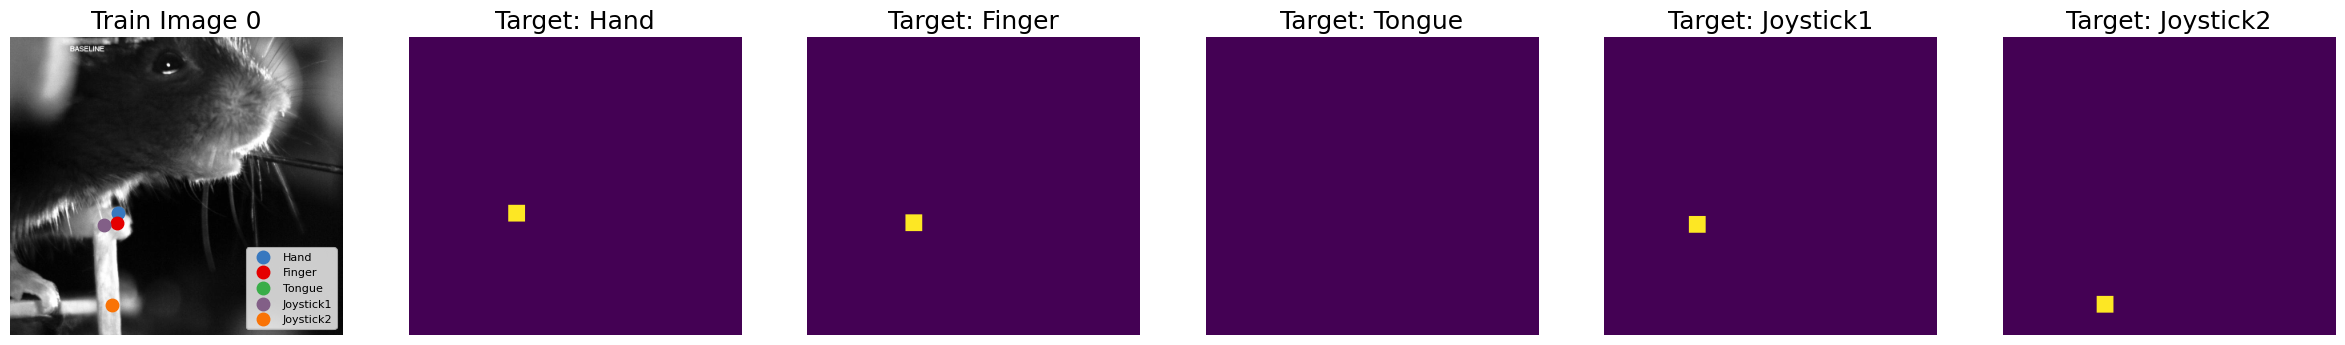

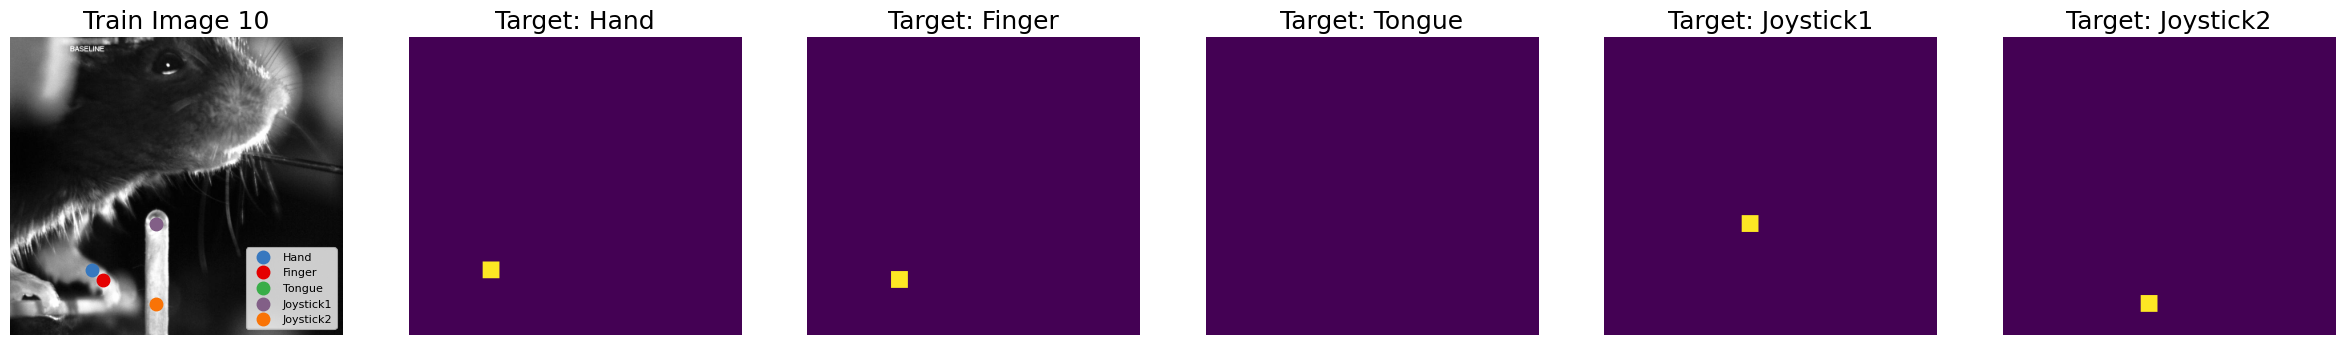

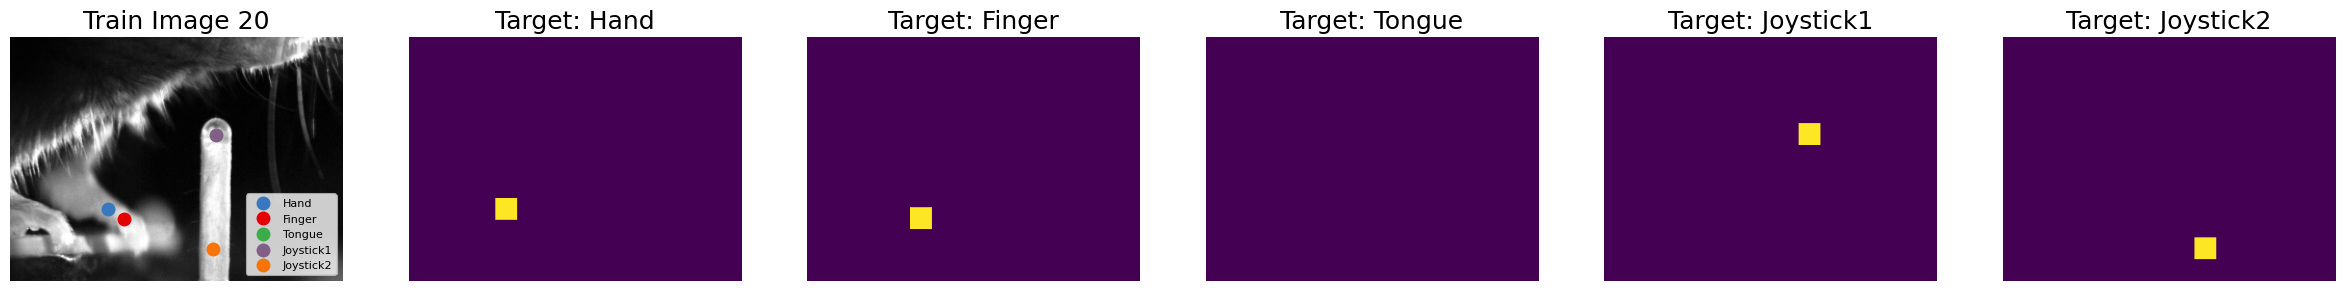

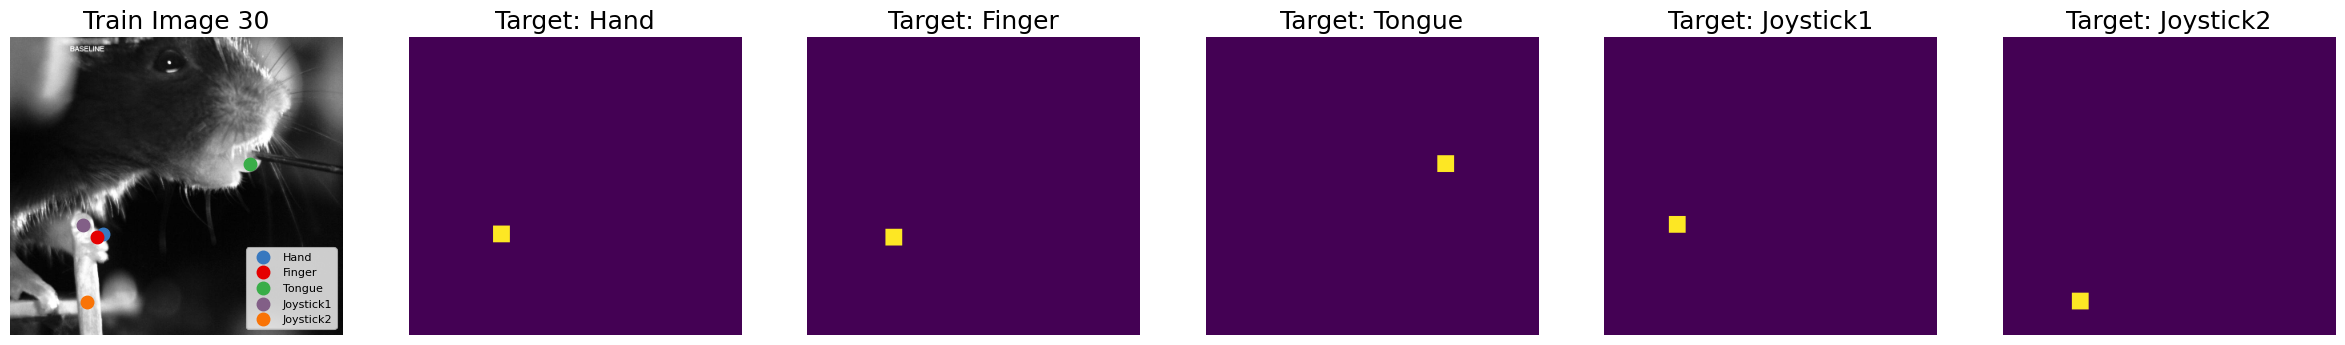

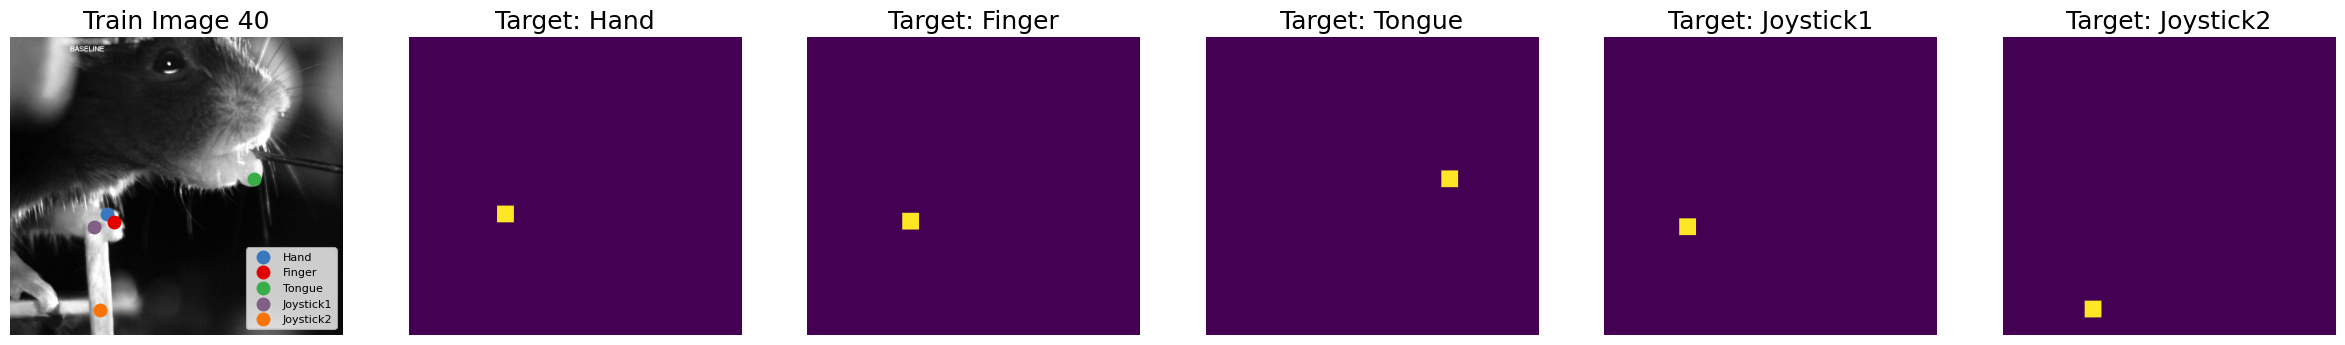

In [8]:
###
# Make the training, validation, and test datasets as described above.
#
# YOUR CODE BELOW
downsample = 2
dilate = 21

train_dataset = KeypointDataset(
    train_images,
    train_targets,
    transforms=[
        TransposeAndMove(),
        Normalize(),
        Downsample(downsample),
        DilateTargets(dilate)
    ]
)

val_dataset = KeypointDataset(
    val_images,
    val_targets,
    transforms=[
        TransposeAndMove(),
        Normalize(),
        Downsample(downsample),
        DilateTargets(dilate)
    ]
)

test_dataset = KeypointDataset(
    test_images,
    transforms=[
        TransposeAndMove(),
        Normalize(),
        Downsample(downsample)
    ]
)
###

#Plot the training examples from above but after transformation
for index in [0, 10, 20, 30, 40]:
    plot_example(from_t(train_dataset[index]['image'][0]),
                train_coords[index],
                from_t(train_dataset[index]['targets']),
                downsample=downsample,
                title="Train Image {}".format(index))

# Test
assert train_dataset[0]['image'].shape == (3, 373, 416)
assert train_dataset[0]['targets'].shape == (5, 373, 416)
assert train_dataset[0]['targets'].sum() == 1764
assert val_dataset[0]['image'].shape == (3, 235, 320)
assert val_dataset[0]['targets'].shape == (5, 235, 320)
assert val_dataset[0]['targets'].sum() == 1764
assert test_dataset[0]['image'].shape == (3, 373, 416)
assert test_dataset[0]['targets'] == -1

In [9]:
def train_model(model: nn.Module,
                train_dataset: Dataset,
                val_dataset: Dataset,
                criterion: Callable[[Tensor, Tensor], Tensor],
                num_epochs: int = 200,
                lr: float = 1.0,
                momentum: float = 0.9,
                lr_step_size: int = 100,
                lr_gamma: float = 0.1) -> Tuple[List[float], List[float]]:
    pbar = trange(num_epochs)
    pbar.set_description("---")

    train_dataloader = DataLoader(train_dataset, batch_size=1)
    val_dataloader = DataLoader(val_dataset, batch_size=1)
    dataloaders = dict(train=train_dataloader, val=val_dataloader)

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    scheduler = lr_scheduler.StepLR(optimizer, step_size=lr_step_size,
                                    gamma=lr_gamma)

    train_losses = []
    val_losses = []
    for epoch in pbar:

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0
            running_size = 0
            for datapoint in dataloaders[phase]:
                image = datapoint['image']
                targets = datapoint['targets']
                if phase == "train":
                    with torch.set_grad_enabled(True):
                        optimizer.zero_grad()
                        output = model(image)
                        loss = criterion(output, targets)
                        loss.backward()
                        optimizer.step()
                else:
                    output = model(image)
                    loss = criterion(output, targets)

                assert loss >= 0
                running_loss += loss.item()
                running_size += 1

            running_loss /= running_size
            losses = train_losses if phase == "train" else val_losses
            losses.append(running_loss)

        scheduler.step()

        pbar.set_description("Epoch {:03} Train {:.4f} Val {:.4f}"\
                             .format(epoch, train_losses[-1], val_losses[-1]))
        pbar.update(1)

    return train_losses, val_losses

In [10]:
class BasicPoseTracker(nn.Module):
    def __init__(self,
                 num_keypoints: int,
                 downsample: int = 1,
                 patch_size: int = 121):
        super(BasicPoseTracker, self).__init__()
        self.num_keypoints = num_keypoints
        assert downsample >= 1.0, "downsample factor must be at least 1"
        self.downsample = downsample
        self.patch_size = patch_size

        # compute the effective patch size in the downsampled image
        # round to the nearest odd number so that the convolution is centered.
        self.eff_patch_size = to_odd(patch_size / downsample)

        ###
        # Convolve (in neural net lingo; cross-correlate in stats lingo)
        # the input with a stack of weights. The weights are parameters of
        # the nn.Conv2d layer, initialized below. Its dimensions are 1 (the
        # number of input channels) by K (the number of keypoints) by H by W
        # (the height and width of the patch). Pad the input with (H // 2) and
        # (W // 2) zeros so that the output is the same size as the input.
        # Note that by default the convolution layer also has a learnable bias,
        # which we want.
        #
        # YOUR CODE BELOW
        self.final_conv = nn.Conv2d(
            in_channels=1,
            out_channels=self.num_keypoints,
            kernel_size=self.eff_patch_size,
            padding=self.eff_patch_size // 2
        )
        ###

    def forward(self,
                x: Float[Tensor, "1 3 height width"]
                ) -> Float[Tensor, "1 num_keypoints heigth width"]:
        """
        Run the "forward pass" of the model to produce logits for
        a batch of images `x`.

        x: (1 x 3 x H x W) "batch" of images, where the batch size
           is always 1.

        returns: (1 x K x H x W) batch of logits for each keypoint.
        """
        original_size = x.shape[-2:]

        ###
        # Complete the steps below, which iteratively update
        # `x` by applying a sequence of functions to it.
        #
        # YOUR CODE BELOW

        # 1. Convert to grayscale by taking a mean over
        #    the color channels (axis=1).
        x = x.mean(dim=1, keepdim=True)

        # 2. Further downsample the image by the factor specified above.
        #    Catch warnings in the F.interpolate function.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            x = F.interpolate(
                x,
                scale_factor=1 / self.downsample,
                mode="bilinear"
            )

        # 3. Apply your convolution layer
        x = self.final_conv(x)

        # 4. Interpolate back to the original size
        #    Catch warnings in the interpolate function.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            x = F.interpolate(
                x,
                size=original_size,
                mode="bilinear"
            )
        ###

        return x

In [11]:
# Construct a basic pose tracker with random initial weights.
torch.manual_seed(0)
basic_model = BasicPoseTracker(num_keypoints,
                               downsample=4,
                               patch_size=101)

# Move the model to device (GPU if available)
basic_model = basic_model.to(device)

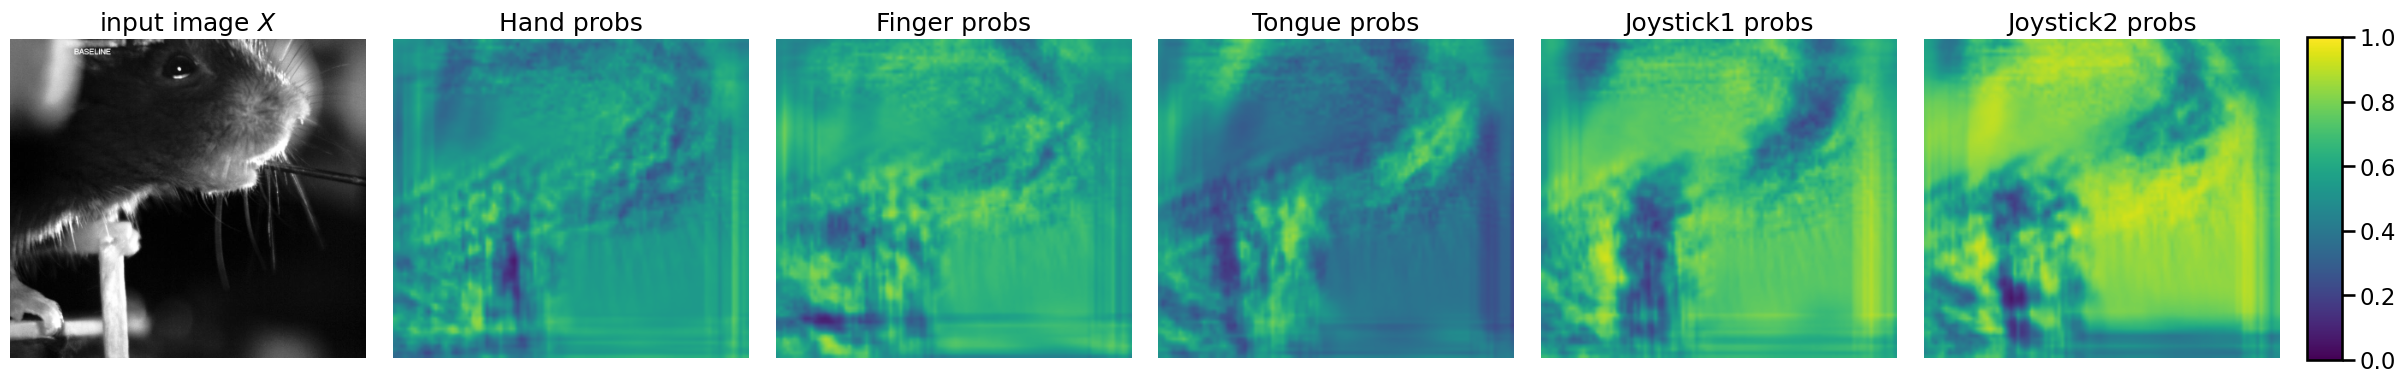

In [14]:
def plot_model_predictions(model: nn.Module,
                           datapoint: Dict[str, Tensor]):
    """Plot the image and the model's predictions
    (i.e. probabilities per pixel) for each of the
    keypoints.
    """
    image = datapoint['image']

    ###
    # Compute the model probabilities $\sigma(A)$.
    # It should be a K x H x W array.
    #
    # YOUR CODE BELOW
    probs = torch.sigmoid(model(image.unsqueeze(0))).squeeze(0)
    ###


    assert probs.shape[0] == num_keypoints
    assert probs.shape[1:] == image.shape[1:]
    plot_image_and_probs(from_t(image), from_t(probs))

# Plot the probabilities output under the initial, random parameters
plot_model_predictions(basic_model, train_dataset[0])

In [ ]:
def bernoulli_loss(logits: Float[Tensor, "num_keypoints height width"],
                   targets: Bool[Tensor, "num_keypoints height width"]
                   ) -> Float:
    """Compute the Bernoulli loss for a single image in the comment above.

    logits:  K x P_H x P_W array of logits ($a_{kij}$)
    targets: K x P_H x P_W array of binary targets ($y_{kij}$)

    returns: scalar average negative log likelihood.
    """
    ###
    # Compute the average negative log likelihood.
    #
    # YOUR CODE BELOW
    log_partition = torch.logaddexp(
        torch.zeros_like(logits),
        logits
    )
    avg_nll = ...
    ###

    return avg_nll


# Test on a single image
image = train_dataset[0]['image']
logits = basic_model(image.unsqueeze(0)).squeeze(0)
targets = train_dataset[0]['targets']
assert torch.isclose(bernoulli_loss(logits, targets),
                     torch.tensor(0.9426), atol=1e-4)

# Test that it works even with potential overflow
logits = 1e3 * torch.ones_like(targets)
assert torch.isfinite(bernoulli_loss(logits, targets))